# 20. U-Net 구조 파악

이 노트북은 `19_FCN_핵심_아이디어.ipynb` 다음 단계로, segmentation에서 널리 사용되는 U-Net 구조를 이해하는 것이 목표입니다.

FCN은 classification CNN을 dense prediction 모델로 바꾸는 중요한 관점을 제시했습니다. U-Net은 이 관점을 더 명확한 **encoder-decoder 구조**로 정리하고, encoder의 feature를 decoder로 직접 전달하는 **skip connection**을 적극적으로 사용합니다.

이번 노트북의 목표는 다음과 같습니다.

- U-Net이 왜 encoder-decoder 구조를 사용하는지 이해합니다.
- downsampling과 upsampling의 역할을 구분합니다.
- skip connection이 위치 정보 복원에 왜 중요한지 이해합니다.
- segmentation 출력이 입력 이미지와 같은 공간 크기를 가져야 한다는 점을 확인합니다.


## 20-1. 준비

이번 노트북은 실제 U-Net 학습보다는 구조 이해에 집중합니다. feature map 크기 변화를 간단한 그림과 표로 확인합니다.


In [1]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font_name in available_fonts:
        plt.rcParams['font.family'] = font_name
        break

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.unicode_minus'] = False


## 20-2. U-Net은 왜 U자 모양인가?

U-Net은 크게 두 부분으로 나눌 수 있습니다.

- Encoder: 이미지를 점점 작게 만들면서 의미 정보를 추출합니다.
- Decoder: 작아진 feature map을 다시 키우면서 픽셀 단위 예측을 복원합니다.

왼쪽에서 해상도가 줄어들고, 오른쪽에서 다시 커지는 모양이 U자처럼 보이기 때문에 U-Net이라고 부릅니다.


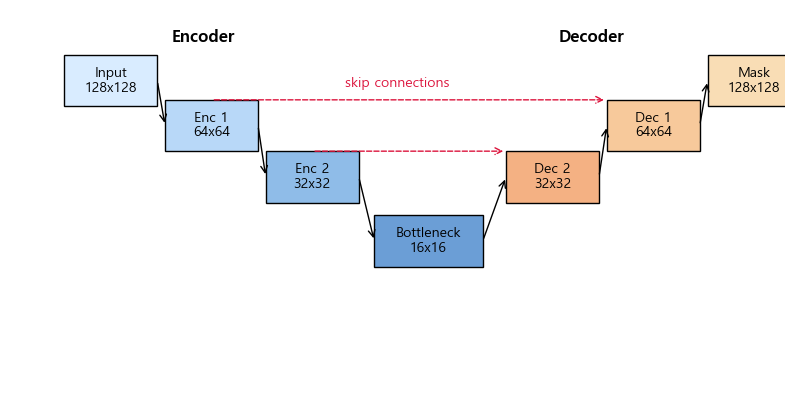

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

blocks = [
    ('Input\n128x128', 0.7, 4.5, 1.2, 0.8, '#d9ecff'),
    ('Enc 1\n64x64', 2.0, 3.8, 1.2, 0.8, '#b8d8f8'),
    ('Enc 2\n32x32', 3.3, 3.0, 1.2, 0.8, '#8fbce8'),
    ('Bottleneck\n16x16', 4.7, 2.0, 1.4, 0.8, '#6b9ed6'),
    ('Dec 2\n32x32', 6.4, 3.0, 1.2, 0.8, '#f4b183'),
    ('Dec 1\n64x64', 7.7, 3.8, 1.2, 0.8, '#f7c99b'),
    ('Mask\n128x128', 9.0, 4.5, 1.2, 0.8, '#f9ddb5'),
]

for text, x, y, w, h, color in blocks:
    ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='black'))
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', fontsize=10)

arrow_pairs = [(1.9, 4.9, 2.0, 4.2), (3.2, 4.2, 3.3, 3.4), (4.5, 3.4, 4.7, 2.4),
               (6.1, 2.4, 6.4, 3.4), (7.6, 3.4, 7.7, 4.2), (8.9, 4.2, 9.0, 4.9)]
for x1, y1, x2, y2 in arrow_pairs:
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=12))

skip_pairs = [(2.6, 4.6, 7.7, 4.6), (3.9, 3.8, 6.4, 3.8)]
for x1, y1, x2, y2 in skip_pairs:
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=12,
                                 linestyle='--', color='crimson'))

ax.text(2.5, 5.5, 'Encoder', ha='center', fontsize=12, fontweight='bold')
ax.text(7.5, 5.5, 'Decoder', ha='center', fontsize=12, fontweight='bold')
ax.text(5.0, 4.8, 'skip connections', ha='center', color='crimson')
plt.show()


## 20-3. Encoder: 의미 정보를 추출한다

Encoder는 일반적인 CNN backbone과 비슷합니다. convolution으로 feature를 만들고, pooling 또는 stride convolution으로 공간 크기를 줄입니다.

공간 크기가 줄어들수록 각 feature는 더 넓은 영역을 보고 판단하게 됩니다. 그래서 깊은 층은 `이 영역이 자동차인가`, `사람인가`, `도로인가` 같은 의미 판단에 강해집니다.


In [3]:
encoder_shapes = [
    ('input', 3, 128, 128),
    ('enc1', 32, 64, 64),
    ('enc2', 64, 32, 32),
    ('enc3', 128, 16, 16),
]

print('Encoder feature shapes')
for name, channels, height, width in encoder_shapes:
    print(f'{name:>6}: channels={channels:>3}, height={height:>3}, width={width:>3}')


Encoder feature shapes
 input: channels=  3, height=128, width=128
  enc1: channels= 32, height= 64, width= 64
  enc2: channels= 64, height= 32, width= 32
  enc3: channels=128, height= 16, width= 16


## 20-4. Decoder: 해상도를 복원한다

Decoder는 encoder에서 작아진 feature map을 다시 키웁니다. segmentation은 최종적으로 입력 이미지와 같은 크기의 mask를 내야 하므로 upsampling 과정이 필요합니다.

Decoder는 단순히 크기만 키우는 것이 아니라, convolution을 함께 사용해 각 위치의 클래스 예측을 점점 정교하게 만듭니다.


In [4]:
decoder_shapes = [
    ('bottleneck', 128, 16, 16),
    ('dec2', 64, 32, 32),
    ('dec1', 32, 64, 64),
    ('output', 2, 128, 128),
]

print('Decoder feature shapes')
for name, channels, height, width in decoder_shapes:
    print(f'{name:>10}: channels={channels:>3}, height={height:>3}, width={width:>3}')


Decoder feature shapes
bottleneck: channels=128, height= 16, width= 16
      dec2: channels= 64, height= 32, width= 32
      dec1: channels= 32, height= 64, width= 64
    output: channels=  2, height=128, width=128


## 20-5. Skip connection: 위치 정보를 되살린다

Encoder의 깊은 feature는 의미 정보가 강하지만, downsampling을 반복하면서 세밀한 위치 정보가 약해집니다. Decoder가 이것만 가지고 mask를 복원하면 경계가 거칠어질 수 있습니다.

U-Net은 같은 해상도 단계의 encoder feature를 decoder feature와 결합합니다. 이렇게 하면 decoder는 깊은 의미 정보와 얕은 위치 정보를 함께 사용할 수 있습니다.

보통 feature를 결합할 때는 channel 방향으로 이어 붙이는 concatenate 연산을 사용합니다.


In [5]:
decoder_feature = (64, 32, 32)  # channels, height, width
encoder_skip = (64, 32, 32)
concat_feature = (decoder_feature[0] + encoder_skip[0], 32, 32)

print('decoder feature:', decoder_feature)
print('encoder skip feature:', encoder_skip)
print('after concatenate:', concat_feature)


decoder feature: (64, 32, 32)
encoder skip feature: (64, 32, 32)
after concatenate: (128, 32, 32)


## 20-6. U-Net의 핵심 흐름

U-Net의 전체 흐름은 다음처럼 정리할 수 있습니다.

```text
image -> encoder -> bottleneck -> decoder + skip connections -> segmentation mask
```

FCN과 마찬가지로 U-Net도 픽셀 단위 예측을 수행합니다. 차이는 U-Net이 encoder와 decoder를 대칭적으로 구성하고, 각 단계의 skip connection을 매우 명확하게 사용한다는 점입니다.


## 20-7. 정리

- U-Net은 segmentation을 위한 encoder-decoder 구조입니다.
- Encoder는 해상도를 줄이며 의미 정보를 추출합니다.
- Decoder는 해상도를 키우며 픽셀 단위 예측을 복원합니다.
- Skip connection은 encoder의 위치 정보를 decoder에 전달합니다.
- 최종 출력은 보통 입력 이미지와 같은 높이와 너비를 가진 mask 또는 class logits입니다.
- 다음 노트북에서는 작은 U-Net 형태의 모델로 간단한 binary segmentation 실습을 수행합니다.
